In [1]:
# 패키지 준비

from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
# 데이터 준비 1
diabetes_dataset = load_diabetes()
# print( diabetes_dataset['DESCR'] ) # 제공된 데이터셋에 대한 설명

X = diabetes_dataset['data']
y = diabetes_dataset['target']

In [3]:
# 데이터 준비 2 - 훈련 데이터 세트 / 테스트 데이터 세트 분할

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42) # 회귀 목적 데이터인 경우 stratify 사용할 필요 없음

In [4]:
# 모델 생성

lin_reg_model =  LinearRegression()

In [5]:
# 모델 훈련
lin_reg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 모델 훈련 결과 확인
print( lin_reg_model.coef_, lin_reg_model.intercept_ ) # coef_ : w1 ~ wn, intercept_ : w0

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743] 151.34560453985995


In [ ]:
# 모델 테스트 (평가) 1

lin_reg_model.score(X_train, y_train), lin_reg_model.score(X_test, y_test)

(0.5279193863361498, 0.4526027629719197)

In [9]:
# 모델 테스트 (평가) 2

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

predicted_train_values = lin_reg_model.predict(X_train)
predicted_test_values = lin_reg_model.predict(X_test)

mean_absolute_error(y_train, predicted_train_values),\
mean_absolute_error(y_test, predicted_test_values),\
mean_squared_error(y_train, predicted_train_values),\
mean_squared_error(y_test, predicted_test_values),\
root_mean_squared_error(y_train, predicted_train_values),\
root_mean_squared_error(y_test, predicted_test_values)

(43.4835035239804,
 42.79409467959994,
 2868.5497028355776,
 2900.19362849348,
 53.55884336723094,
 53.853445836765914)

In [ ]:
# 규제가 추가된 모델 사용

In [11]:
# 패키지 추가

from sklearn.linear_model import Ridge, Lasso

In [ ]:
# 데이터 준비는 LinearRegression 모델 훈련에서 구현한 내용으로 대신합니다.

In [ ]:
# Ridge 모델 학습

scores = []
weights = []
for r in [10, 1, 0.1, 0.01, 0.001]: # 규제항을 조정하면서 모델 훈련 반복
    ridge_model = Ridge(alpha=r) # 규제 강도를 적용한 Ridge 모델 생성
    ridge_model.fit(X_train, y_train)
    train_score = ridge_model.score(X_train, y_train)
    test_score = ridge_model.score(X_test, y_test)
    scores.append( (r, train_score, test_score)  )
    weights.append( (r, ridge_model.coef_) ) # 매 규제 강도에 따른 가중치를 목록에 저장

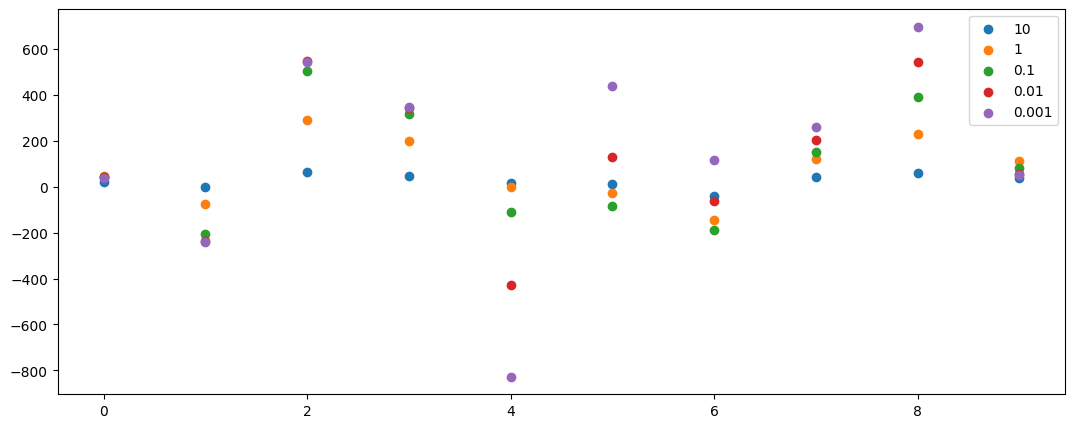

In [16]:
# 규제 강도에 따라 가중치가 어떻게 변하는지 확인

import matplotlib.pyplot as plt

# for w in weights:
#     plt.scatter(range(len(w[1])), w[1])

plt.figure(figsize=(13, 5))
for r, w in weights:
    plt.scatter(range(len(w)), w, label=str(r)) # w : 가중치, r : 규제 강도

plt.legend()
plt.show()

In [ ]:
# 각 규제 정도별 훈련 및 테스트 평가 결과 확인 --> 규제 0.1이 최적 모델을 만듭니다.
scores

[(10, 0.163322412645444, 0.161225867509881),
 (1, 0.4424027835503953, 0.41915292635986545),
 (0.1, 0.5206068569960087, 0.46085219464119254),
 (0.01, 0.5261789624217001, 0.4559819504579109),
 (0.001, 0.5278457170674613, 0.4534280301019331)]

In [19]:
# Lasso 모델 학습

scores = []
weights = []
for r in [10, 1, 0.1, 0.01, 0.001]: # 규제항을 조정하면서 모델 훈련 반복
    lasso_model = Lasso(alpha=r) # 규제 강도를 적용한 Ridge 모델 생성
    lasso_model.fit(X_train, y_train)
    train_score = lasso_model.score(X_train, y_train)
    test_score = lasso_model.score(X_test, y_test)
    scores.append( (r, train_score, test_score)  )
    weights.append( (r, lasso_model.coef_) ) # 매 규제 강도에 따른 가중치를 목록에 저장

In [20]:
# 각 규제 정도별 훈련 및 테스트 평가 결과 확인 --> 규제 0.1이 최적 모델을 만듭니다.
scores

[(10, 0.0, -0.011962984778542296),
 (1, 0.3646309911295581, 0.3575918767219115),
 (0.1, 0.5169410847799543, 0.4718547867276227),
 (0.01, 0.5265153773726006, 0.45668611945806237),
 (0.001, 0.5278884667308259, 0.4533169443449512)]

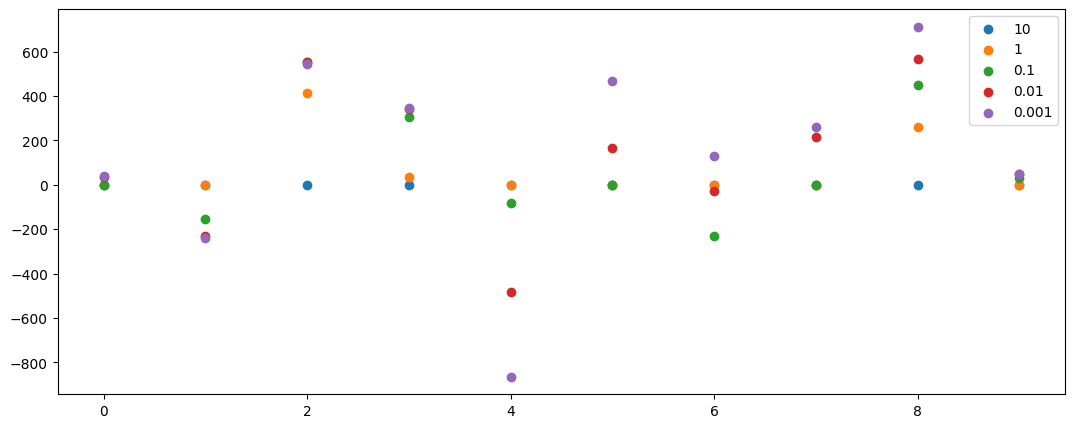

In [21]:
# 규제 강도에 따라 가중치가 어떻게 변하는지 확인

plt.figure(figsize=(13, 5))
for r, w in weights:
    plt.scatter(range(len(w)), w, label=str(r)) # w : 가중치, r : 규제 강도

plt.legend()
plt.show()